# Lab 8: Binary Tree Traversals

Lecturer: <code>Sirasit Lochanachit</code>

Course: 

<code>01526102 Data Structures and Algorithms [SIIE]
</code>

Term: <code>02/2025</code>

---

# Pre-requisites
* On local machine, please install graphviz first: https://www.graphviz.org/download/.
* On Colab, it is already pre-installed, no need to reinstall it.

Then install graphviz package

In [ ]:
!pip install graphviz

# Tree Visualization using graphviz

In [27]:
import graphviz
from IPython.display import display

In [28]:
dot = graphviz.Digraph()
for e in ['a', 'b', 'c', 'd', 'e', 'f']:
    dot.node(e)
dot.edge('a', 'b')
dot.edge('a', 'c')
dot.edge('b', 'd')
dot.edge('b', 'e')
dot.edge('c', 'f')

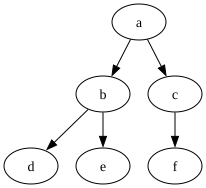

In [29]:
# Viewing the binary tree
display(dot)                                            # Display the tree within the jupyter notebook
#dot.view()                                            # Save the tree as a pdf file
#dot.render('binary_tree', view=True, format='png')   # Save the tree as a png file

# Exercise: Visualize the following binary tree with your code

In [ ]:
dot1 = graphviz.Digraph()
########################
## Add your code here
########################

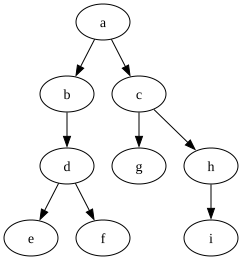

In [31]:
display(dot1)

# Lab 8-1: Implement a Tree using List of Lists (Array).

The code below create a small binary tree with left and right subtrees

In [ ]:
smallTree = ['A',   #root 
             ['B',  #left subtree
              ['D', [], []],    # A subtree that has a root value and two empty lists are leaf nodes
              ['E', [], []] ],  # A subtree that has a root value and two empty lists are leaf nodes
             ['C',  #right subtree
              ['F', [], []],    # A subtree that has a root value and two empty lists are leaf nodes
              []]
             ]

In [ ]:
print(smallTree)

In [ ]:
print('root = ', smallTree[0])
print('left subtree = ', smallTree[1])
print('right subtree = ', smallTree[2])

In [ ]:
print('leaf node D =', smallTree[1][1] )

The `BinaryTree_Array` function creates a list with a root node and two empty sublists for the children.

In [ ]:
def BinaryTree_Array(r):
    return [r, [], []]

*   To add a left subtree to the root, a new list has to be inserted into the 2nd position (1st index) of the root list.
    * However, if there is already a node in that position, the new list needs to be pused down the tree as the left child of the list.
*   Similarly, adding a right subtree can be executed by inserting into the 3rd position (2nd index) of the root list.

## 1.1 Problem Description
Given basic insertion methods of a binary tree as defined below, 

1. implement an **insert_right** method that insert a right child to the binary tree

## Requirement
- Accepts two inputs - root node and the value
- Use only List operations

In [ ]:
""" Insertion methods """
def insertLeft(root: list, newBranch):
    t = root.pop(1)                       # Obtain list that corresponds to the current left child of the root
    if len(t) > 1:                        # If the left child is not empty, push the old left child as the left child of the new node.
      root.insert(1, [newBranch, t, []])
    else:                                 # If the left child is empty
      root.insert(1, [newBranch,[],[]])
    return root

def insertRight(root: list, newBranch):
    ##################################
    ### Add your code here
    ##################################
    return root

""" Accessor methods """
def getRootVal(root: list):
    return root[0]

def setRootVal(root: list, newVal):
    root[0] = newVal

def getLeftChild(root):
    return root[1]

def getRightChild(root: list):
    return root[2]

### Running Code Examples

In [ ]:
r = BinaryTree_Array(3)    # contents = [3, [], []]
insertLeft(r,4)      # contents = [3, [4, [], []], []]
insertLeft(r,5)      # contents = [3, [5, [4, [], []], []], []]
insertRight(r,6)     # contents = [3, [5, [4, [], []], []], [6, [], []]]
insertRight(r,7)     # contents = [3, [5, [4, [], []], []], [7, [], [6, [], []]]] 
l = getLeftChild(r)   # [5, [4, [], []], []]
print(l)

In [ ]:
setRootVal(l,9)      # contents = [3, [9, [4, [], []], []], [7, [], [6, [], []]]] 
print(r)
insertLeft(l,11)     # contents = [3, [9, [11, [4, [], []], []], []], [7, [], [6, [], []]]] 
print(r)
print(getRightChild(getRightChild(r)))  # [6, [], []]

---

# Lab 8-2: Implement a Binary Tree using Nodes and References (Linked Lists) with non-recursive approach on Insertion.

## 2.1 Problem Description
Given a `BinaryTreeNode` class as defined below, 

1. implement an **insertRight** method that insert a right child to the binary tree

## Requirement
- Accepts one input - a `BinaryTreeNode`
- Use only linked list references/pointers

The class below create a single node of a binary tree and associated references/pointers which can be used to refer to left or right child.

In [ ]:
class BinaryTreeNode:
    """ Tree implementation using node and reference"""
    def __init__(self, key, element):
        self._key = key                # key value for the node
        self._element = element        # reference to user’s element
        self._leftChild = None         # reference to left child
        self._rightChild = None        # reference to right child
    
    """ Insertion methods """
    def insertLeft(self, newNode: BinaryTreeNode):
        if self._leftChild == None:    # No existing left child, add a node to the left
            self._leftChild = newNode
        else:                         # Insert a node and pust the old child down one level
            newNode._leftChild = self._leftChild
            self._leftChild = newNode
        
    
    def insertRight(self, newNode: BinaryTreeNode):
        ##################################
        ### Add your code here
        ##################################

    """ Accessor methods """
    def getRightChild(self):
        return self._rightChild

    def getLeftChild(self):
        return self._leftChild

    def setRootVal(self,e):
        self._element = e

    def getRootVal(self):
        return self._element

The class below creates a binary tree using linked list
- it contains the root node and size of the tree

In [31]:
class BinaryTree_LL:
    def __init__(self, root):
        self._root = BinaryTreeNode(None, root)
        self._size = 0
    
    def node_count(self):
        return self._size
    
    def visualize_binary_tree_key(self):
        dot = graphviz.Digraph()
        dot.node(str(self._root._key))

        def add_nodes_edges(node):
            if node._leftChild:
                dot.node(str(node._leftChild._key))
                dot.edge(str(node._key), str(node._leftChild._key))
                add_nodes_edges(node._leftChild)
            if node._rightChild:
                dot.node(str(node._rightChild._key))
                dot.edge(str(node._key), str(node._rightChild._key))
                add_nodes_edges(node._rightChild)

        add_nodes_edges(self._root)

        # Viewing the binary tree
        display(dot)                                            # Display the tree within the jupyter notebook
        #dot.view()                                            # Save the tree as a pdf file
        #dot.render('binary_tree', view=True, format='png')   # Save the tree as a png file

### Running Code Examples - Add nodes into the binary tree

1. Create a root node with a specified key and element 
2. Create a new tree and assign the created root node into the tree
3. Increase node count by 1

In [ ]:
r = BinaryTreeNode(1,'a')                   # contents = [a, [], []]
binary_tree = BinaryTree_LL(r)               # contents = [a, [], []]
binary_tree._size += 1

print(r.getRootVal())
print(r.getLeftChild())

4. Add a new node to the left of the root node (left child) and increase node count by 1

In [ ]:
node1 = BinaryTreeNode(2,'b')
r.insertLeft(node1)                     # contents = [a, [b, [], []], []]
binary_tree._size += 1

print(r.getLeftChild().getRootVal())

5. Add a new node to the right of the root node (right child) and increase node count by 1

In [ ]:
node2 = BinaryTreeNode(3,'c')
r.insertRight(node2)                    # contents = [a, [b, [], []], [c, [], []]]
binary_tree._size += 1

print(r.getRightChild().getRootVal())

6. Assign the value of root node's right child

In [ ]:
r.getRightChild().setRootVal('hello') # contents = [a, [b, [], []], [hello, [], []]]
print(r.getRightChild().getRootVal())

7. Get node count

In [ ]:
binary_tree.node_count()

8. Add a new node to the right of root node's right child and increase node count by 1

In [ ]:
r.getRightChild().insertRight(BinaryTreeNode(4,'world'))
print(r.getRightChild().getRightChild().getRootVal())

9. Visualise the binary tree with a key

In [ ]:
binary_tree.visualize_binary_tree_key()

---

#  Lab 8-3: Implement Depth-first Traversal Algorithms


## 3.1 Problem Description

Given a `BinaryTree_LL` class as defined below, 
- Implement three helper methods: `preorder(root)`, `inorder(root)`, and `postorder(root)`.

## Requirements
- **traverse()**
   - **Goal:** Display the tree’s content in three different orders.
   - The `traverse()` method should call these helper methods and display the output clearly labeled as “Preorder:”, “Inorder:”, and “Postorder:” respectively.
- `preorder(root)`, `inorder(root)`, and `postorder(root)`
   - For each method, print out the arrow `->` along with the root's key.
      - For instance, -> 1

In [ ]:
class BinaryTree_LL:
    def __init__(self, root=None):
        self._root = root
        self._size = 0

    def length(self):
        return self._size

    def __len__(self):
        return self._size
    
    def __iter__(self):     # In-order traversal
        return self._root.__iter__()
    
    def is_empty(self):
        return self._size == 0
    
    def node_count(self):
        return self._size

    def preorder(self, root):
        ########################
        ## Add your code here
        ########################
        pass

    def inorder(self, root):
        ########################
        ## Add your code here
        ########################
        pass

    def postorder(self, root):
        ########################
        ## Add your code here
        ########################
        pass

    def traverse(self):
        if self.is_empty():
            print("This is an empty tree.")
        else:
            print("Preorder: ")
            self.preorder(self._root)
            print("\nInorder: ")
            self.inorder(self._root)
            print("\nPostorder: ")
            self.postorder(self._root)
            print("")
        
    def visualize_binary_tree_key(self):
        dot = graphviz.Digraph()
        dot.node(str(self._root._key))

        def add_nodes_edges(node):
            if node._leftChild:
                dot.node(str(node._leftChild._key))
                dot.edge(str(node._key), str(node._leftChild._key))
                add_nodes_edges(node._leftChild)
            if node._rightChild:
                dot.node(str(node._rightChild._key))
                dot.edge(str(node._key), str(node._rightChild._key))
                add_nodes_edges(node._rightChild)

        add_nodes_edges(self._root)

        # Viewing the binary tree
        display(dot)                                            # Display the tree within the jupyter notebook
        #dot.view()                                            # Save the tree as a pdf file
        #dot.render('binary_tree', view=True, format='png')   # Save the tree as a png file

### Running Code Examples (continued from Lab 8-2)

9. Display Depth-first Traversal results

In [46]:
binary_tree.traverse()

Preorder: 
-> 1 -> 2 -> 3 -> 4 
Inorder: 
-> 2 -> 1 -> 3 -> 4 
Postorder: 
-> 2 -> 4 -> 3 -> 1 


---

## Lab 8-4: Test with The Example Tree from the Lecture

## 4.1 Problem Description

Given an example binary tree as defined below in the picture, your task is to replicate this example tree by perform the following tasks:
1. Write a code to add nodes into the tree by using methods from `BinaryTreeNode` and `Binary_TreeLL`
2. Display depth-first traversal results
3. Visualise the binary tree with a key

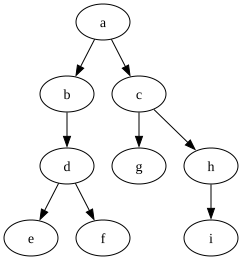

In [ ]:
## Example Binary Tree from the lecture

1. Add nodes into the binary tree

2. Display depth-first traversal results

3. Visualise the binary tree with a key

---